# Analysis of drops falling in cups, filmed from above

## 1. Documentation and Imports


Created on Wed Jan 27 2021

Author: Valentin Laplaud

The purpose of this code is to analyze drop experiment filmed from above. 
It should be able to detect drop exiting the cups and to track them to obtain 
a velocity using the trackpy library (http://soft-matter.github.io/trackpy/v0.4.2/)

In [111]:

from __future__ import division, unicode_literals, print_function 
 # for compatibility with Python 2 and 3

# plotting stuff
import matplotlib as mpl
import matplotlib.pyplot as plt

# numbers handling
import numpy as np
import pandas as pd

import pims # image handling
import trackpy as tp # tracking library

import random
random.seed() # random number generator (no seed)

DebugPlots = True # Display intermediate plots along the way

## 2. Define analysis functions

### 2.1 Loading stack and locating objects

Identification of objects on each image of the stack

In tp.locate/batch :

'21' is the estimate size (in px) of particles to track.

'minmass' is the minimal mass (integrated pixel value) for a particule, it is really high because image are 16bits, it may be easier to convert in 8bits before

Image grayscale is inverted as trackpy looks for bright objects

In [122]:
def LoadAndLocate(filename):
    
    stack = pims.open(filename) # get the tiff stack
    features = tp.batch(stack[:], 21, minmass=100000, invert=True); # equivalent to tp.locate but on all frames specified
    
    if DebugPlots == True: # Debug plots
        nimg = random.randrange(len(stack)) # takes a random image in the stack, can be changed for specific debuging
        testF = tp.locate(stack[nimg], 21, minmass=100000, invert=True) # analyze only this image
        plt.figure
        plt.title('Frame number ' + str(nimg))
        tp.annotate(testF,stack[nimg]) # plot features identification
    
    return(stack, features)

### 2.2 Link located particles into trajectories

Creation of trajectories. 

In tp.link() : 

'5' here is the maximum displacement allowed between two images. the higher it is the longer it wil take for the program to run.

'memory = 2' is the maximum of image a particule can disapear and still be considered part of the same trajectory when it reapears

In [123]:
def MakeTraj(features):
    tracks = tp.link(f, 5, memory = 2 )
    return tracks

## X. Enter data and run

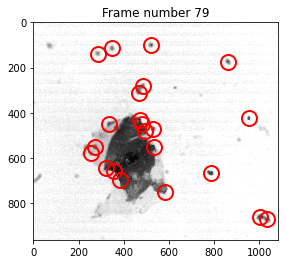

In [121]:

P = r'd:\Users\Valentin Laplaud\PostDoc\Data\21.01.22_ObservationFromAbove'

ExpList = ['C4_75cm_S08-4']

for s in ExpList:
    stack, features = LoadAndLocate(P + '\\' + s + '.tif')
    



# Test zone

In [ ]:
nimg

(array([2., 2., 4., 1., 4., 5., 5., 0., 1., 2.]),
 array([5.40303549, 5.51996351, 5.63689152, 5.75381953, 5.87074755,
        5.98767556, 6.10460358, 6.22153159, 6.3384596 , 6.45538762,
        6.57231563]),
 <BarContainer object of 10 artists>)

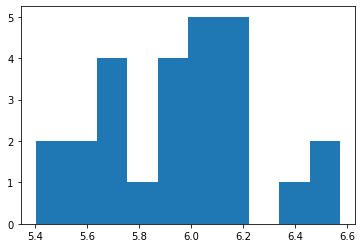

In [39]:
fig, ax = plt.subplots()
ax.hist(features['size'])

In [38]:
tp.locate?

In [107]:
len(stack)

110

In [82]:
stack

<Frames>
Source: d:\Users\Valentin Laplaud\PostDoc\Data\21.01.22_ObservationFromAbove\C4_75cm_S08-4.tif
Length: 110 frames
Frame Shape: (963, 1084)
Pixel Datatype: uint16

In [71]:
stack?

In [80]:
stack[1].frame_no




1